In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from argparse import Namespace
from plot_params import *

METHOD_NAME = "OPAS"
RUNS = {dataset: torch.load(f"data/times_{dataset}.pkl") for dataset in ['audio', 'speech', 'cifar', 'lsun']}
SEP = "�"
PM = "±"

In [32]:
err_markersize = 12
opas_markersize = 300
opas_idmarkersize = opas_markersize - 1
axis_fontsize = 25
title_fontsize = 25
label_fontsize = 15
legend_fontsize = 20

def plot_map_vs_time_allinone(time_mu, MAP_mu, MAP_std, opas_time, opas_map, labels, colors, title=None, axes=None, save_path=None, logscale=False, ylabel=True):
    if axes is None:
        if title == "MASS":
            fig, ax2 = plt.subplots(figsize=(7,5))
            ax1 = ax2
            logscale = True
            ax2.scatter(opas_time[0], opas_map[0], marker='*', s=opas_idmarkersize, color='black', label=METHOD_NAME)
        else:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7,5), sharey=True, gridspec_kw={'width_ratios': [1, 3]})
    else:
        if title == "MASS":
            fig, ax2 = axes
            ax1 = ax2
            logscale = True
            ax2.scatter(opas_time[0], opas_map[0], marker='*', s=opas_idmarkersize, color='black', label=METHOD_NAME)
        else:
            fig, ax1, ax2 = axes

    if logscale:
        ax1.set_xscale('log')
        ax2.set_xscale('log')


    for i in range(len(time_mu)):
        ax1.errorbar(time_mu[i], MAP_mu[i], MAP_std[i], linestyle='-', c=colors[i], linewidth=1, elinewidth=0.5, marker='^', markersize=err_markersize, label=labels[i], capsize=2)
        label2 = None if title == "MASS" else labels[i]
        ax2.errorbar(time_mu[i], MAP_mu[i], MAP_std[i], linestyle='-', c=colors[i], linewidth=1, elinewidth=0.5, marker='^', markersize=err_markersize, label=label2, capsize=2)

        ax1.scatter(opas_time[i], opas_map[i], marker='*', s=opas_markersize, color=colors[i])
        ax2.scatter(opas_time[i], opas_map[i], marker='*', s=opas_markersize, color=colors[i])
    
    # ax1.text(coords[0], coords[1], METHOD_NAME, fontsize=10)

    ax1.set_axisbelow(True)
    ax2.set_axisbelow(True)
    ax1.grid(linewidth=0.2)
    ax2.grid(linewidth=0.2)

    if ylabel:    
        ax1.set_ylabel("MAP", fontsize=axis_fontsize)
    ax2.set_xlabel("Time (ms)", fontsize=axis_fontsize)
    
    ax1.tick_params(axis='both', which='major', labelsize=label_fontsize)
    ax2.tick_params(axis='both', which='major', labelsize=label_fontsize)

    if title == "MASS":
        # ax2.legend(loc='lower right')
        ax2.set_title(title, x=0.5, y=1.02, fontsize=title_fontsize)
        if save_path is not None:
            plt.savefig(save_path)
        return None

    ax2.xaxis.set_label_coords(0.25, -0.12)
    ax2.set_title(title, x=0.25, y=1.02, fontsize=title_fontsize)
    
    mintime = min([min(t) for t in time_mu])
    maxtime = max([max(t) for t in time_mu])

    opas_lims = 0.7 * opas_time.min(), 1.1 * opas_time.max()
    method_lims = 0.93 * mintime, 1.03 * maxtime
    
    if title.lower() == "fastdtw":
        method_lims = 0.98 * mintime, 1.02 * maxtime

    ax2.scatter(method_lims[0]-0.05, 0.5, marker='*', s=opas_idmarkersize, color='black', label=METHOD_NAME)

    ax1.set_xlim(*opas_lims)       # opas-line
    ax2.set_xlim(*method_lims)     # main-data

    # ax2.legend(loc='lower right')

    # hide the spines between ax and ax2
    ax1.spines.right.set_visible(False)
    ax2.spines.left.set_visible(False)
    ax2.tick_params(labelleft=False)
    ax1.yaxis.tick_left()
    ax2.yaxis.tick_right()
    # ax1.set_xticklabels(list(map(lambda x: f"{x:.3f}", ax1.get_xticks())), rotation=35)
    # ax2.set_xticklabels(list(map(lambda x: f"{x:.2f}", ax2.get_xticks())), rotation=35)


    for tick in ax2.yaxis.get_major_ticks():
        tick.tick1line.set_visible(False)
        tick.tick2line.set_visible(False)
    
    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([1, 1], [1, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [1, 0], transform=ax2.transAxes, **kwargs)
    
    if save_path is not None and axes is None:
        plt.savefig(save_path)

    if axes is not None:
        return ax2.get_legend_handles_labels()

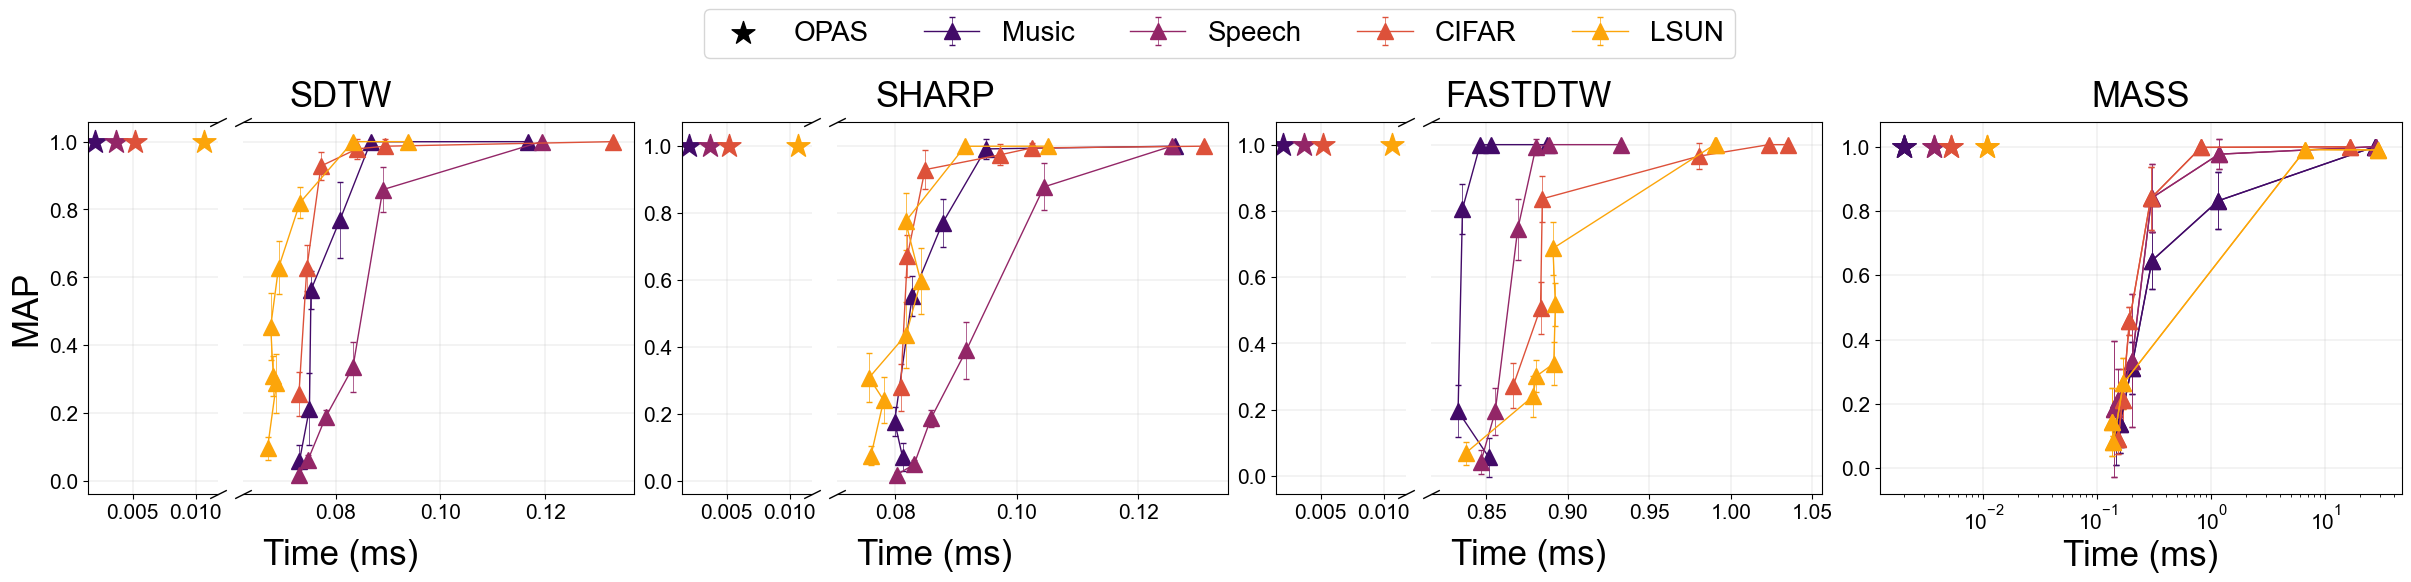

In [33]:
figsize = (24, 5)
fig, ax = plt.subplots(1, 7, figsize=figsize, constrained_layout=True, width_ratios=[1,3,1,3,1,3,4])

for n, method in enumerate(["sdtw", "sharp", "fastdtw", "mass"]):
    # if method != "mass": continue
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7,5), sharey=True, gridspec_kw={'width_ratios': [1, 3]})
    colors = plt.cm.inferno(np.linspace(0.2, 0.8, 4))
    
    collated_time, collated_map_mu, collated_map_std = [], [], []
    ptime, pmap, pmrr = [], [], []

    datasets = []
    for nn, (dataset, runs) in enumerate(RUNS.items()):
        # if dataset == "lsun": continue
        if dataset == "audio":
            opas_time, opas_map, opas_mrr = 0.0020, 1, 1
        elif dataset == "speech":
            opas_time, opas_map, opas_mrr = 0.0037, 0.9992, 0.9992
        elif dataset == "cifar":
            opas_time, opas_map, opas_mrr = 0.0052, 1, 1
        elif dataset == "lsun":
            opas_time, opas_map, opas_mrr = 0.0107, 1, 1
        else: 
            raise ValueError(f"Unknown dataset {dataset}")
        
        if dataset in ['cifar', 'lsun']:
            datasets.append(dataset.upper())
        else:
            datasets.append(dataset.capitalize())

        method_time = []
        method_map = []
        method_mrr = []
        for run in runs:
            data = getattr(run, method, None)
            if data is None: 
                continue
            skip, time, MAP, MRR = data
            time_mu, time_std = list(map(float, time.split(SEP)))
            MAP_mu, MAP_std = list(map(float, MAP.split(SEP)))
            MRR_mu, MRR_std = list(map(float, MRR.split(SEP)))
            method_time.append([time_mu, time_std])
            method_map.append([MAP_mu, MAP_std])
            method_mrr.append([MRR_mu, MRR_std])

        method_time, method_map, method_mrr = list(map(np.array, [method_time, method_map, method_mrr]))
        sl = slice(1,None,None) if dataset != "lsun" else slice(None)
        time_mu, time_std = method_time[sl].T
        MAP_mu, MAP_std = method_map[sl].T
        MRR_mu, MRR_std = method_mrr[sl].T

        if method == "mass" and dataset == "lsun":
            time_mu = time_mu[:-3]
            MAP_mu = MAP_mu[:-3]
            MAP_std = MAP_std[:-3]

        collated_time.append(time_mu)
        collated_map_mu.append(MAP_mu)
        collated_map_std.append(MAP_std)
        ptime.append(opas_time)
        pmap.append(opas_map)
        pmrr.append(opas_mrr)

    if method == "mass":
        axs = [fig, ax[-1]]
    else:
        axs = [fig, ax[n*2], ax[n*2+1]]

    opas_time, opas_map = np.array(ptime), np.array(pmap)
    ret = plot_map_vs_time_allinone(collated_time, collated_map_mu, collated_map_std, opas_time, opas_map, datasets, colors, title=method.upper(), axes=axs, ylabel=(method == "sdtw"))
    if method == "fastdtw":
        handles, labels = ret
        labels = ["Music" if i == "Audio" else i for i in labels]

        legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=legend_fontsize)
        coords = legend.get_window_extent().get_points()[0]
        fig.legends = []
        scale = fig.get_window_extent().get_points()[1]
        fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+legend_fontsize/70), loc=2, ncol=5, fontsize=legend_fontsize)

fig.savefig("map_vs_time.pdf", bbox_inches='tight')
plt.show()